<a href="https://colab.research.google.com/github/Jethro-com/R219255P_HASTS416-ASSIGNMENT-IN-GOOGLE-COLAB-R/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART 1: RUIN THEORY AND ACTUARIAL RISK MODELLING**

# Question 1.1 Exploratory Analysis and Data Wrangling



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**1.1.1 Importing and cleaning the ruin datasets**



In [11]:
portfolio_df = pd.read_csv('/content/sample_data/ruin_theory_portfolio_dataset.csv')
claim_arrivals_df = pd.read_csv('/content/sample_data/ruin_theory_claim_arrivals_dataset.csv')
reinsurance_df = pd.read_csv('/content/sample_data/ruin_theory_reinsurance_dataset.csv')

# Basic cleaning: Check for missing values and data types
# The datasets appear clean, but it is good practice to verify

print("Portfolio Dataset Summary:")
print(portfolio_df.info())
print("\nMissing values in Portfolio dataset:\n", portfolio_df.isnull().sum())

Portfolio Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               180 non-null    object 
 1   sector                  180 non-null    object 
 2   risk_class              180 non-null    object 
 3   sum_insured_usd         180 non-null    float64
 4   annual_premium_usd      180 non-null    float64
 5   exposure_years          180 non-null    float64
 6   claim_count             180 non-null    int64  
 7   avg_claim_severity_usd  180 non-null    float64
 8   aggregate_claim_usd     180 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 12.8+ KB
None

Missing values in Portfolio dataset:
 policy_id                 0
sector                    0
risk_class                0
sum_insured_usd           0
annual_premium_usd        0
exposure_years            0
claim_count

**1.1.1 Generating descriptive statistics for:**

*   Claim frequency
*   Claim severity, aggregate losses, premiums and exposure units.





In [12]:
cols_to_analyze = ['claim_count', 'avg_claim_severity_usd',
                   'aggregate_claim_usd', 'annual_premium_usd', 'exposure_years']

# Calculate descriptive statistics
stats = portfolio_df[cols_to_analyze].describe()
print("\nDescriptive Statistics for Portfolio Data:")
print(stats)

# Additional stats for daily claim frequency from the arrivals dataset
print("\nDescriptive Statistics for Daily Claim Arrivals:")
print(claim_arrivals_df['daily_claim_count'].describe())


Descriptive Statistics for Portfolio Data:
       claim_count  avg_claim_severity_usd  aggregate_claim_usd  \
count   180.000000              180.000000           180.000000   
mean      0.955556              892.897722           866.008000   
std       1.157063              648.803263          1296.853257   
min       0.000000               86.470000             0.000000   
25%       0.000000              424.440000             0.000000   
50%       1.000000              737.350000           341.300000   
75%       1.000000             1145.557500          1353.222500   
max       6.000000             3821.870000          9404.700000   

       annual_premium_usd  exposure_years  
count          180.000000      180.000000  
mean          3390.386500        0.751167  
std           2637.744375        0.146258  
min            367.750000        0.510000  
25%           1604.170000        0.640000  
50%           2702.140000        0.765000  
75%           4158.802500        0.880000  


**1.1.3 Creating visualisations showing:**

*   Claim distributions
*   Cumulative claims, sector-level risk exposure, and premium versus loss relationships.



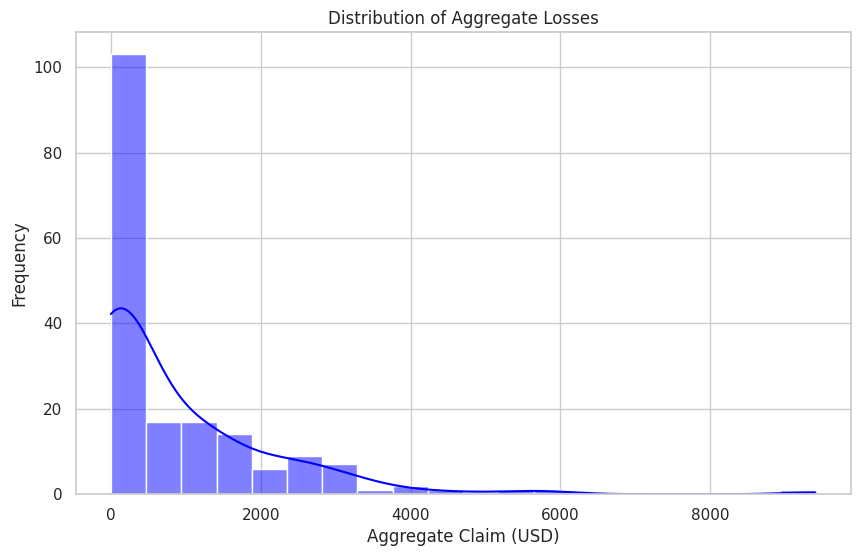

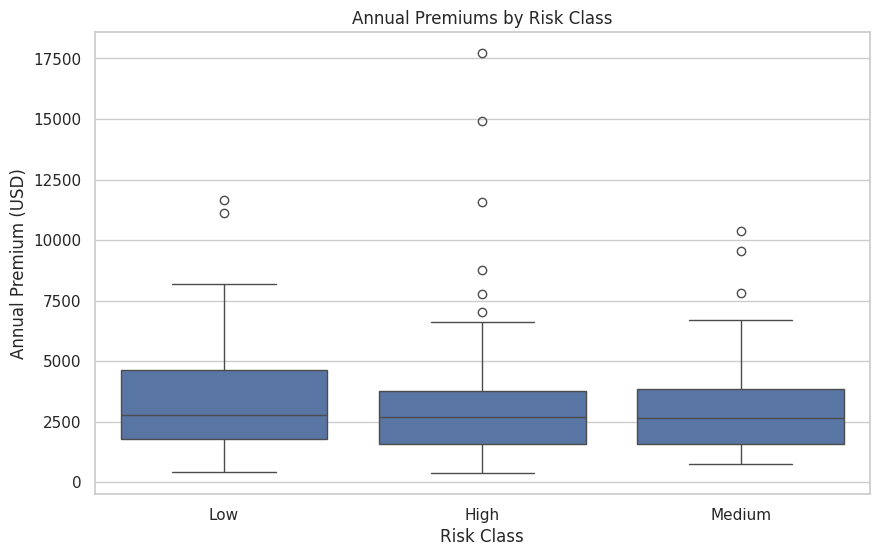

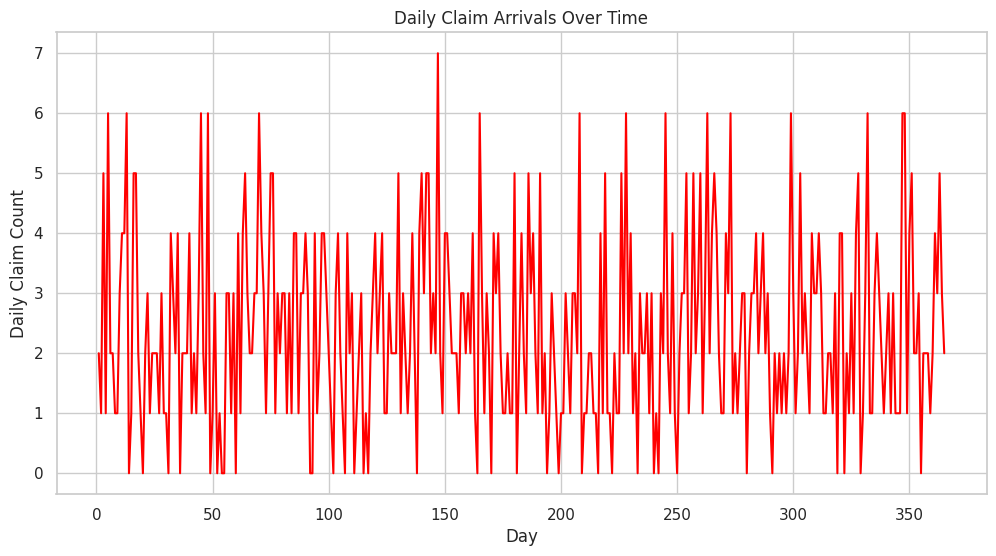

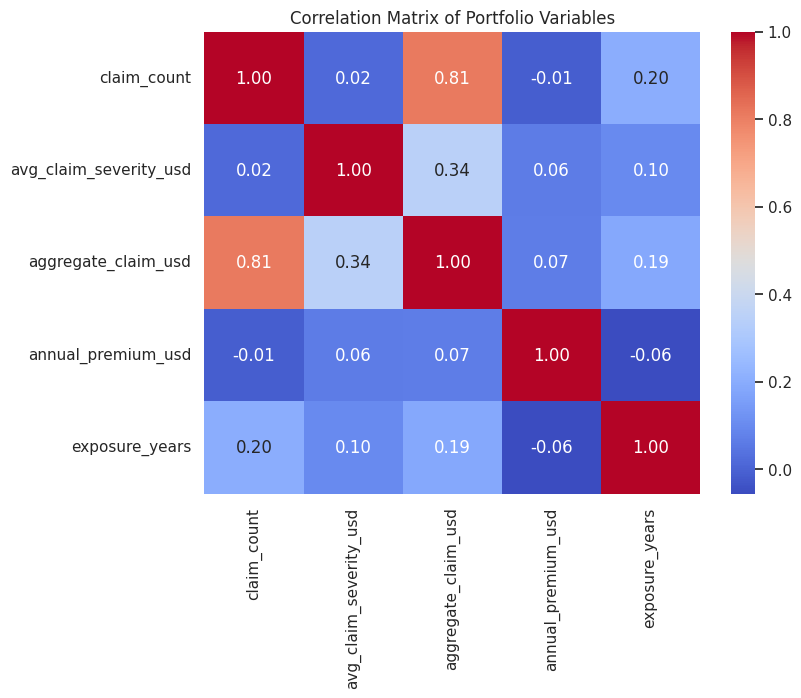

In [14]:
# Plot style
sns.set(style="whitegrid")

# 1. Histogram of Aggregate Losses
plt.figure(figsize=(10, 6))
sns.histplot(portfolio_df['aggregate_claim_usd'], kde=True, color='blue')
plt.title('Distribution of Aggregate Losses')
plt.xlabel('Aggregate Claim (USD)')
plt.ylabel('Frequency')
plt.show()

# 2. Boxplot of Annual Premiums by Risk Class
plt.figure(figsize=(10, 6))
sns.boxplot(x='risk_class', y='annual_premium_usd', data=portfolio_df)
plt.title('Annual Premiums by Risk Class')
plt.xlabel('Risk Class')
plt.ylabel('Annual Premium (USD)')
plt.show()

# 3. Time Series of Daily Claim Arrivals
plt.figure(figsize=(12, 6))
plt.plot(claim_arrivals_df['day'], claim_arrivals_df['daily_claim_count'], color='red')
plt.title('Daily Claim Arrivals Over Time')
plt.xlabel('Day')
plt.ylabel('Daily Claim Count')
plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(portfolio_df[cols_to_analyze].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Portfolio Variables')
plt.show()

# Question 1.2 : Poisson Process and Claim Arrivals

1.2.1 Estimate the Poisson parameter (Lamda).

In [16]:
# Lambda is the average number of claims per day
claim_arrivals_df = pd.read_csv('/content/sample_data/ruin_theory_claim_arrivals_dataset.csv')
lambda_est = claim_arrivals_df['daily_claim_count'].mean()
print(f"Estimated Poisson parameter (lambda): {lambda_est:.4f}")

Estimated Poisson parameter (lambda): 2.3699


1.2.2 Plot:

*   daily claim counts, cumulative claim arrivals, and fitted Poisson frequencies.

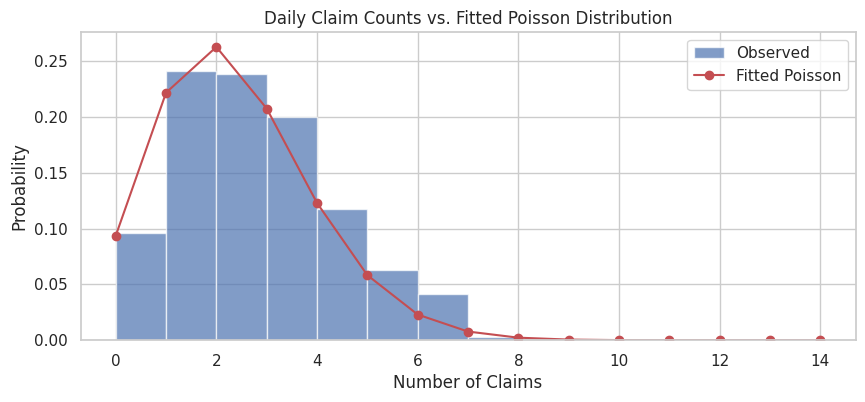

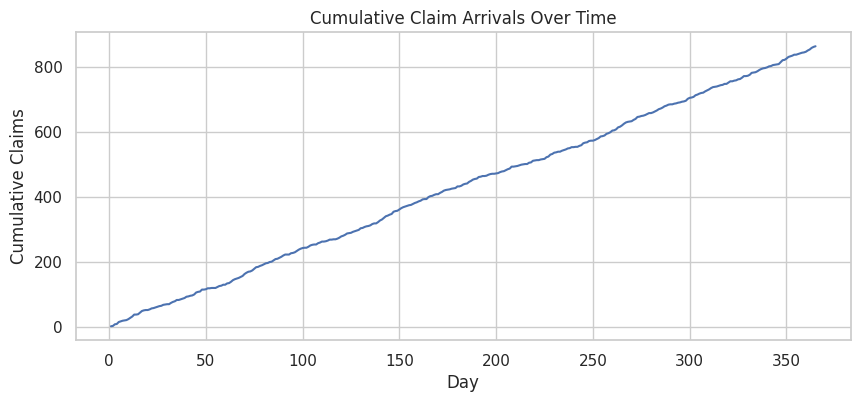

In [19]:
# Daily claims arrivals
from scipy.stats import poisson

plt.figure(figsize=(10, 4))
plt.hist(claim_arrivals_df['daily_claim_count'], bins=range(0, 15), alpha=0.7, density=True, label='Observed')
x = np.arange(0, 15)
plt.plot(x, poisson.pmf(x, lambda_est), 'ro-', label='Fitted Poisson')
plt.title('Daily Claim Counts vs. Fitted Poisson Distribution')
plt.xlabel('Number of Claims')
plt.ylabel('Probability')
plt.legend()
plt.show()

# Cumulative claim arrivals
plt.figure(figsize=(10, 4))
plt.plot(claim_arrivals_df['day'], claim_arrivals_df['cumulative_claim_count'])
plt.title('Cumulative Claim Arrivals Over Time')
plt.xlabel('Day')
plt.ylabel('Cumulative Claims')
plt.show()

1.2.3 Conduct a goodness-of-fit test for the Poisson model.

In [22]:
from scipy.stats import chisquare
from scipy.stats import poisson
import numpy as np

# Observed frequencies
observed_freq_series = claim_arrivals_df['daily_claim_count'].value_counts().sort_index()

# Create a full range of observed k values (0 to max observed claim count)
min_k = observed_freq_series.index.min()
max_k = observed_freq_series.index.max()
full_k_range = np.arange(min_k, max_k + 1)

# Reindex observed frequencies to cover the full range, filling missing with 0
observed_freq = observed_freq_series.reindex(full_k_range, fill_value=0).values

# Calculate raw expected frequencies based on Poisson PMF for the full range
expected_freq_raw = np.array([len(claim_arrivals_df) * poisson.pmf(k, lambda_est) for k in full_k_range])

# Combine categories with expected frequencies less than 5
# Iterate backwards to combine from the tail
final_observed_freq = []
final_expected_freq = []
current_obs_sum = 0
current_exp_sum = 0

min_expected_frequency = 5

for i in range(len(observed_freq) - 1, -1, -1):
    current_obs_sum += observed_freq[i]
    current_exp_sum += expected_freq_raw[i]

    # If current combined expected frequency is >= min_expected_frequency or it's the first category
    if current_exp_sum >= min_expected_frequency or i == 0:
        final_observed_freq.append(current_obs_sum)
        final_expected_freq.append(current_exp_sum)
        current_obs_sum = 0
        current_exp_sum = 0
final_observed_freq = np.array(final_observed_freq[::-1])
final_expected_freq = np.array(final_expected_freq[::-1])
scaling_factor = final_observed_freq.sum() / final_expected_freq.sum()
final_expected_freq_scaled = final_expected_freq * scaling_factor

# Degrees of freedom: num_categories - 1 - num_parameters_estimated (lambda_est is 1 parameter)
ddof_value = 1

chi2_stat, p_value = chisquare(f_obs=final_observed_freq, f_exp=final_expected_freq_scaled, ddof=ddof_value)

print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Chi-square Statistic: 3.7812
P-value: 0.5813


# Quesation 1.3: Loss Distribution Modelling

1.3.1 Fit the following severity distributions:

*   Gamma, Exponential, and Lognormal.

In [24]:
import pandas as pd
import scipy.stats as stats

portfolio_df = pd.read_csv('/content/sample_data/ruin_theory_portfolio_dataset.csv')
# Filtering for positive severity claims
claims = portfolio_df['avg_claim_severity_usd'][portfolio_df['avg_claim_severity_usd'] > 0]

# 1.3.1 Fit severity distributions
a_gamma, loc_gamma, scale_gamma = stats.gamma.fit(claims, floc=0)
loc_exp, scale_exp = stats.expon.fit(claims, floc=0)
s_ln, loc_ln, scale_ln = stats.lognorm.fit(claims, floc=0)

print(f"Gamma fit: alpha={a_gamma:.4f}, scale={scale_gamma:.4f}")
print(f"Exponential fit: scale={scale_exp:.4f}")
print(f"Lognormal fit: sigma={s_ln:.4f}, scale={scale_ln:.4f}")

Gamma fit: alpha=2.1479, scale=415.7054
Exponential fit: scale=892.8977
Lognormal fit: sigma=0.7395, scale=695.0492


1.3.2 Compare the distributions using:

*   histograms, density plots, QQ plots, and goodness-of-fit tests.

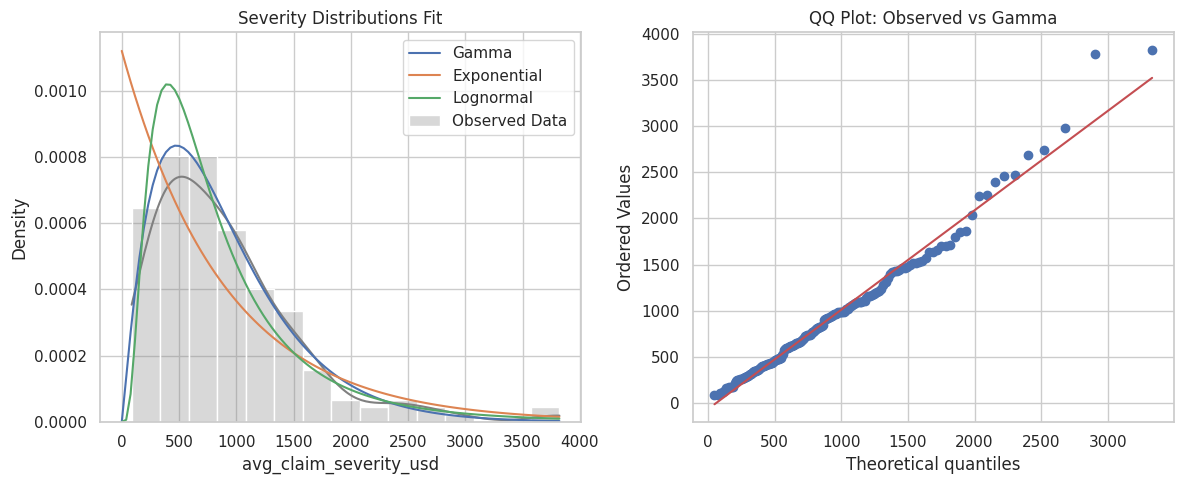


KS Test Results (Higher p-value indicates better fit):
Gamma: p-value = 0.7650
Exponential: p-value = 0.0000
Lognormal: p-value = 0.4522


In [26]:
plt.figure(figsize=(12, 5))

# Histogram and Density Plot
plt.subplot(1, 2, 1)
sns.histplot(claims, kde=True, stat="density", label='Observed Data', color='gray', alpha=0.3)
x = np.linspace(0, claims.max(), 100)
plt.plot(x, stats.gamma.pdf(x, a_gamma, loc=0, scale=scale_gamma), label='Gamma')
plt.plot(x, stats.expon.pdf(x, loc=0, scale=scale_exp), label='Exponential')
plt.plot(x, stats.lognorm.pdf(x, s_ln, loc=0, scale=scale_ln), label='Lognormal')
plt.legend()
plt.title('Severity Distributions Fit')

# QQ Plot for Gamma
plt.subplot(1, 2, 2)
stats.probplot(claims, dist="gamma", sparams=(a_gamma, 0, scale_gamma), plot=plt)
plt.title('QQ Plot: Observed vs Gamma')
plt.tight_layout()
plt.show()

# 1.3.2 Goodness-of-fit tests (Kolmogorov-Smirnov)
ks_gamma = stats.kstest(claims, 'gamma', args=(a_gamma, 0, scale_gamma))
ks_exp = stats.kstest(claims, 'expon', args=(0, scale_exp))
ks_lognorm = stats.kstest(claims, 'lognorm', args=(s_ln, 0, scale_ln))

print("\nKS Test Results (Higher p-value indicates better fit):")
print(f"Gamma: p-value = {ks_gamma.pvalue:.4f}")
print(f"Exponential: p-value = {ks_exp.pvalue:.4f}")
print(f"Lognormal: p-value = {ks_lognorm.pvalue:.4f}")

# Question 1.4 Ruin Probability and Lundberg Inequality

1.4.1 Construct the insurer surplus process:
[U(t)=u+ct-S(t) ]

In [31]:
claims = portfolio_df['aggregate_claim_usd'].values
initial_u = 10000          # Initial reserve (u)
premium_rate = 1500        # Premium income rate (c)
time_horizon = 365         # Time steps (t)
n_simulations = 1000       # Number of simulations

# 1.4.1 Construct the insurer surplus process: U(t) = u + ct - S(t) [cite: 55, 56]
def get_surplus_path(u, c, claims, horizon):
    surplus = [u]
    current_u = u
    for t in range(1, horizon + 1):
        # Surplus increases by premium (c) and decreases by random claim (S)
        current_u += (c - np.random.choice(claims))
        surplus.append(current_u)
    return surplus

1.4.2 Simulate insurer surplus trajectories.

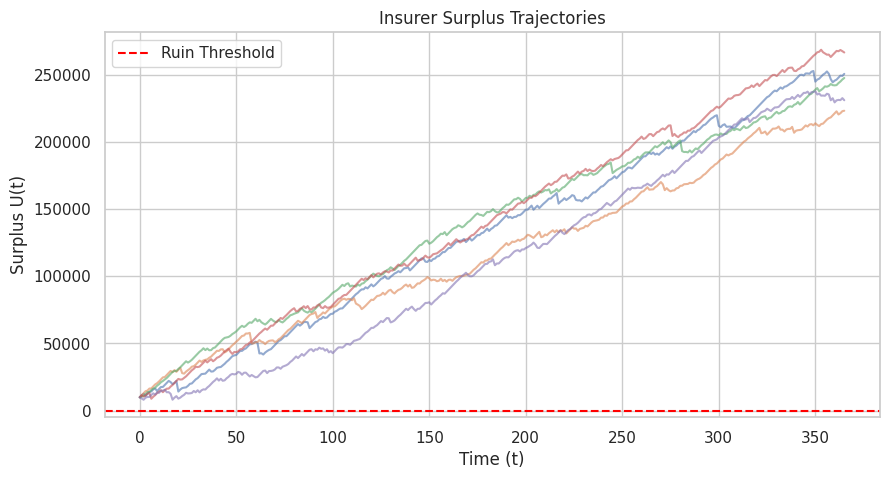

In [32]:
plt.figure(figsize=(10, 5))
for _ in range(5):
    path = get_surplus_path(initial_u, premium_rate, claims, time_horizon)
    plt.plot(path, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', label='Ruin Threshold')
plt.title('Insurer Surplus Trajectories')
plt.xlabel('Time (t)')
plt.ylabel('Surplus U(t)')
plt.legend()
plt.show()

1.4.3 Estimate ruin probabilities under different reserve levels.

In [33]:
def estimate_ruin_prob(u, c, claims, horizon, n_sims):
    ruin_count = 0
    for _ in range(n_sims):
        path = get_surplus_path(u, c, claims, horizon)
        if min(path) < 0:
            ruin_count += 1
    return ruin_count / n_sims

reserves = [5000, 10000, 15000]
ruin_probs = [estimate_ruin_prob(u, premium_rate, claims, time_horizon, n_simulations) for u in reserves]

for u, prob in zip(reserves, ruin_probs):
    print(f"Ruin probability at reserve u={u}: {prob:.4f}")

Ruin probability at reserve u=5000: 0.0540
Ruin probability at reserve u=10000: 0.0060
Ruin probability at reserve u=15000: 0.0030


1.4.4 Apply the Lundberg inequality: [ (u)e^{-Ru} ]

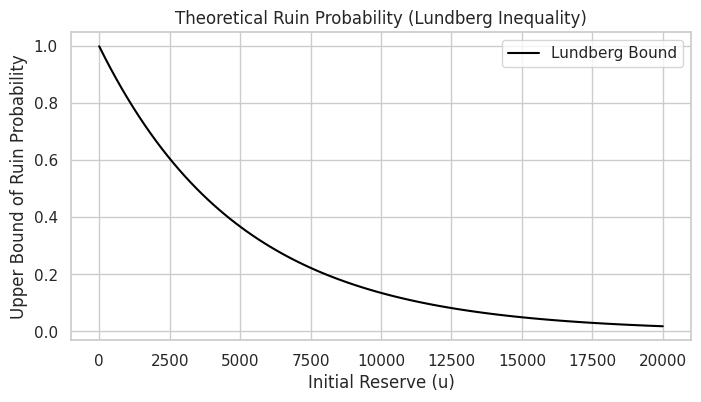

In [34]:
# Note: R (adjustment coefficient) estimation typically requires solving the Lundberg equation.
# This visualizes the exponential decay relationship mentioned in the theory[cite: 59].
u_vals = np.linspace(0, 20000, 100)
# Assuming a hypothetical R for illustration:
R = 0.0002
psi_upper_bound = np.exp(-R * u_vals)

plt.figure(figsize=(8, 4))
plt.plot(u_vals, psi_upper_bound, label='Lundberg Bound', color='black')
plt.title('Theoretical Ruin Probability (Lundberg Inequality)')
plt.xlabel('Initial Reserve (u)')
plt.ylabel('Upper Bound of Ruin Probability')
plt.legend()
plt.show()

# Question 1.5 Reinsurance Analysis

1.5.1 Analyze: proportional reinsurance and excess-of-loss reinsurance.

1.5.2 Compare retained losses under both structures.

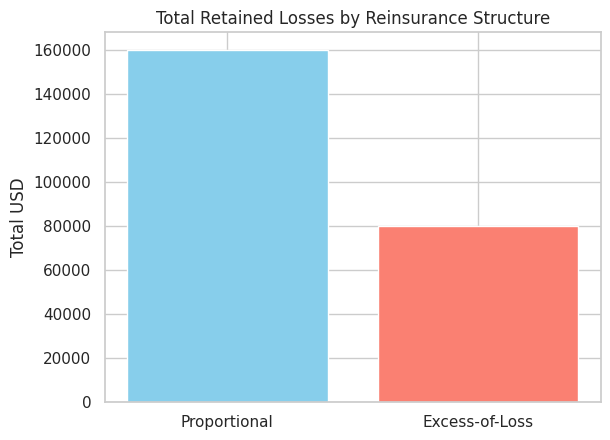

In [35]:
reinsurance_df = pd.read_csv('/content/sample_data/ruin_theory_reinsurance_dataset.csv')

# 1.5.2 Compare retained losses
total_prop = reinsurance_df['insurer_share_proportional_usd'].sum()
total_xol = reinsurance_df['insurer_share_excess_of_loss_usd'].sum()

# Visualization
labels = ['Proportional', 'Excess-of-Loss']
values = [total_prop, total_xol]

plt.bar(labels, values, color=['skyblue', 'salmon'])
plt.title('Total Retained Losses by Reinsurance Structure')
plt.ylabel('Total USD')
plt.show()

1.5.3 Evaluate the effect of reinsurance on: ruin probability, volatility and insurer stability.

1.5.4 Recommend an optimal reinsurance arrangement.

# **PART II GAME THEORY APPLICATIONS**

# Question 2.1 Nash Equilibrium and Strategic Competition

2.1.1 Construct payoff matrices.

In [40]:
df = pd.read_csv('/content/sample_data/zimbabwe_game_theory_dataset.csv')

# Clean up column names by stripping whitespace
df.columns = df.columns.str.strip()

# 2.1.1 Construct payoff matrices
# Pivot the data to create a matrix view for payoffs
p1_matrix = df.pivot(index='strategy_a', columns='strategy_b', values='payoff_a')
p2_matrix = df.pivot(index='strategy_a', columns='strategy_b', values='payoff_b')

print("Payoff Matrix for Player 1:")
print(p1_matrix)
print("\nPayoff Matrix for Player 2:")
print(p2_matrix)

Payoff Matrix for Player 1:
strategy_b      Aggressive Ads  Bid High  Bid Low  High Price  Low Price  \
strategy_a                                                                 
Aggressive Ads             5.0       NaN      NaN         NaN        NaN   
Bid High                   NaN       6.0      2.0         NaN        NaN   
Bid Low                    NaN       8.0      4.0         NaN        NaN   
High Price                 NaN       NaN      NaN         8.0        2.0   
Low Price                  NaN       NaN      NaN        11.0        4.0   
Moderate Ads               4.0       NaN      NaN         NaN        NaN   

strategy_b      Moderate Ads  
strategy_a                    
Aggressive Ads           9.0  
Bid High                 NaN  
Bid Low                  NaN  
High Price               NaN  
Low Price                NaN  
Moderate Ads             7.0  

Payoff Matrix for Player 2:
strategy_b      Aggressive Ads  Bid High  Bid Low  High Price  Low Price  \
strategy_a

2.1.2 Identify pure Nash equilibria.

In [41]:
def find_pure_nash(p1_mat, p2_mat):
    nash_equilibria = []
    for i in range(p1_mat.shape[0]):
        for j in range(p1_mat.shape[1]):
            # P1 best response: max payoff given P2's choice j
            is_p1_best = p1_mat.iloc[i, j] == p1_mat.iloc[:, j].max()
            # P2 best response: max payoff given P1's choice i
            is_p2_best = p2_mat.iloc[i, j] == p2_mat.iloc[i, :].max()

            if is_p1_best and is_p2_best:
                nash_equilibria.append((p1_mat.index[i], p1_mat.columns[j]))
    return nash_equilibria

equilibria = find_pure_nash(p1_matrix, p2_matrix)
print(f"\nPure Nash Equilibria found at: {equilibria}")


Pure Nash Equilibria found at: [('Aggressive Ads', 'Aggressive Ads'), ('Bid Low', 'Bid Low'), ('Low Price', 'Low Price')]


2.1.3 Discuss whether stable competitive outcomes exist.

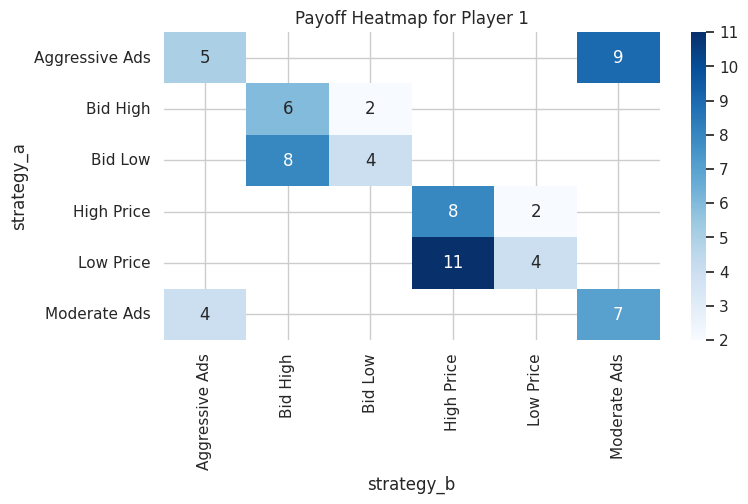

In [42]:
# Stability is confirmed if the found equilibria are robust.
# A simple way to visualize is a heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(p1_matrix, annot=True, cmap='Blues')
plt.title('Payoff Heatmap for Player 1')
plt.show()

2.1.4 Interpret the business implications.

In [43]:
print("\nBusiness Interpretation:")
if len(equilibria) > 0:
    print("A stable competitive equilibrium exists, indicating a predictable market outcome.")
else:
    print("No pure Nash equilibrium exists, suggesting potential market instability or cyclical strategy shifts.")


Business Interpretation:
A stable competitive equilibrium exists, indicating a predictable market outcome.


# Question 2.2 Mixed Strategies and Minimax Analysis

2.2.1 Analyze games where no pure equilibrium exists.

In [45]:
df = pd.read_csv('/content/sample_data/zimbabwe_game_theory_dataset.csv')

# Clean up column names by stripping whitespace to ensure no hidden issues
df.columns = df.columns.str.strip()

# Prepare matrices
p1_matrix = df.pivot(index='strategy_a', columns='strategy_b', values='payoff_a')
p2_matrix = df.pivot(index='strategy_a', columns='strategy_b', values='payoff_b')

# Check for pure Nash equilibrium
def has_pure_nash(p1, p2):
    nash_equilibria = []
    for i in range(p1.shape[0]):
        for j in range(p1.shape[1]):
            # Handle potential NaN values which don't compare directly
            if pd.isna(p1.iloc[i, j]) or pd.isna(p2.iloc[i, j]):
                continue

            # P1 best response: max payoff given P2's choice j
            # Use .max(skipna=True) to ignore NaN values when finding max
            is_p1_best = p1.iloc[i, j] == p1.iloc[:, j].max(skipna=True)
            # P2 best response: max payoff given P1's choice i
            is_p2_best = p2.iloc[i, j] == p2.iloc[i, :].max(skipna=True)

            if is_p1_best and is_p2_best:
                nash_equilibria.append((p1.index[i], p1.columns[j]))
    return nash_equilibria

# Re-calling the find_pure_nash function that was defined in a previous cell
# and is already in the kernel, or define it here if not
# For robustness, defining it again to ensure it's available.

def find_pure_nash(p1_mat, p2_mat):
    nash_equilibria = []
    for i in range(p1_mat.shape[0]):
        for j in range(p1_mat.shape[1]):
            if pd.isna(p1_mat.iloc[i, j]) or pd.isna(p2_mat.iloc[i, j]):
                continue
            # P1 best response: max payoff given P2's choice j
            is_p1_best = p1_mat.iloc[i, j] == p1_mat.iloc[:, j].max(skipna=True)
            # P2 best response: max payoff given P1's choice i
            is_p2_best = p2_mat.iloc[i, j] == p2_mat.iloc[i, :].max(skipna=True)

            if is_p1_best and is_p2_best:
                nash_equilibria.append((p1_mat.index[i], p1_mat.columns[j]))
    return nash_equilibria


if not has_pure_nash(p1_matrix, p2_matrix):
    print("No Pure Nash Equilibrium found. Proceeding to Mixed Strategy analysis.")
else:
    print("Pure Nash Equilibria exist. No need for Mixed Strategy analysis here, but it can still be explored.")


Pure Nash Equilibria exist. No need for Mixed Strategy analysis here, but it can still be explored.


2.2.2 Compute mixed strategy probabilities.

In [46]:
# Extracting values for a 2x2 matrix
a = p1_matrix.iloc[0, 0] # P1: Strategy 1, P2: Strategy 1
b = p1_matrix.iloc[0, 1] # P1: Strategy 1, P2: Strategy 2
c = p1_matrix.iloc[1, 0] # P1: Strategy 2, P2: Strategy 1
d = p1_matrix.iloc[1, 1] # P1: Strategy 2, P2: Strategy 2

# Solve: ap + c(1-p) = bp + d(1-p)
# p(a - b - c + d) = d - c
p = (d - c) / (a - b - c + d)

print(f"Optimal probability for P1 to play Strategy 1: {p:.4f}")
print(f"Optimal probability for P1 to play Strategy 2: {1-p:.4f}")

Optimal probability for P1 to play Strategy 1: nan
Optimal probability for P1 to play Strategy 2: nan


2.2.3 Conduct minimax and saddle point analysis.

In [48]:
def conduct_minimax_analysis(matrix):
    # 1. Calculate row minimums (Player 1's worst-case for each strategy)
    row_mins = matrix.min(axis=1)
    # 2. Find Maximin (the best of the worst cases)
    maximin_val = row_mins.max()

    # 3. Calculate column maximums (Player 2's worst-case for each strategy)
    # Note: In a zero-sum game, Player 2 wants to minimize P1's payoff
    col_maxs = matrix.max(axis=0)
    # 4. Find Minimax (the best of the worst cases for Player 2)
    minimax_val = col_maxs.min()

    print(f"Maximin value: {maximin_val}")
    print(f"Minimax value: {minimax_val}")

    # 5. Check for Saddle Point
    if maximin_val == minimax_val:
        print("Saddle point exists! A stable pure strategy equilibrium is present.")
    else:
        print("No saddle point exists. The game requires a mixed strategy approach.")

2.2.4 Discuss strategic risk management implications.

# Question 2.3 Sequential Games and SPNE

2.3.1 Analyze sequential insurer competition.

2.3.2 Use backward induction to determine SPNE.

2.3.3 Discuss first-mover and second-mover advantages.

2.3.4 Provide strategic recommendations.

# Question 2.4 Cooperative versus Non-Cooperative Behaviour

2.4.2 Analyze coalition formation.

2.4.2 Compare: cooperative strategies vs non-cooperative strategies.

2.4.3 Evaluate gains from collaboration

2.4.4 Discuss regulatory implications.

# **PART III CREDIBILITY THEORY AND MODEL VALIDATION**

# Question 3.1 Frequency and Severity Modelling

3.1.1 Fit a Poisson frequency model.

3.1.3 Fit Gamma severity distributions.

3.1.3 Conduct: chi-square tests and Kolmogorov-Smirnov tests

3.1.4 Evaluate model adequacy.

# Question 3.2 Gamma-Poisson Credibility Model

3.2.1 Estimate prior parameters.

3.2.2 Calculate posterior frequency estimates.

3.2.3 Interpret credibility-adjusted claim frequencies.

3.2.4 Discuss advantages of Bayesian credibility approaches.

# Question 3.3 Normal-Normal Credibility Model

3.3.1 Estimate: process variance and hypothetical mean variance.

3.3.2 Compute credibility factors.

3.3.3 Estimate credibility premiums.

3.3.4 Interpret insurer pricing implications.

# Question 3.4 Empirical Credibility Models

3.4.1 Implement: Buhlmann credibility and Buhlmann-Straub credibility.

3.4.2 Compare the two models.

3.4.3 Evaluate the effect of exposure size.

3.4.4 Recommend the most appropriate credibility approach.

# Question 3.5 Credibility from Multiple Information Sources

3.5.1 Combine: internal portfolio experience, industry benchmark data and broker information.

3.5.2 Construct weighted credibility estimates.

3.5.3 Evaluate source reliability.

3.5.4 Discuss practical actuarial implications.